In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

from tqdm import tqdm
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
torch.backends.cudnn.benchmark = True



Using device: cuda


In [ ]:

num_epochs = 500
batch_size = 128
lr = 2e-4

nz = 100                # noise dimension
num_classes = 10        
image_size = 28
img_dim = image_size * image_size


In [14]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

label_embedding = nn.Embedding(num_classes, num_classes).to(device)



In [15]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(nz + num_classes, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),

            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_vec = label_embedding(labels)
        x = torch.cat([noise, label_vec], dim=1)
        img = self.model(x)
        return img


In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(img_dim + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img_flat, labels):
        label_vec = label_embedding(labels)
        x = torch.cat([img_flat, label_vec], dim=1)
        validity = self.model(x)
        return validity


In [17]:
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))


In [18]:
G_losses = []
D_losses = []
real_scores = []
fake_scores = []
fixed_noise = torch.randn(80, nz, device=device)
os.makedirs("outputs", exist_ok=True)


In [19]:
for epoch in range(num_epochs):

    epoch_loss_g = 0.0
    epoch_loss_d = 0.0
    epoch_real = 0.0
    epoch_fake = 0.0

    for i, (real_images, class_labels) in enumerate(
        tqdm(train_dl, desc=f"Epoch [{epoch+1}/{num_epochs}]")
    ):

        real_images = real_images.to(device, non_blocking=True)
        class_labels = class_labels.to(device, non_blocking=True)
        b_size = real_images.size(0)

        if epoch == 0 and i == 0:
            print("CUDA available:", torch.cuda.is_available())
            print("Tensor device:", real_images.device)
            print("GPU memory:",
                  torch.cuda.memory_allocated() // (1024**2), "MB")

        real_targets = torch.ones(b_size, 1, device=device)
        fake_targets = torch.zeros(b_size, 1, device=device)

       
        netD.zero_grad(set_to_none=True)

        real_flat = real_images.view(b_size, -1)
        real_out = netD(real_flat, class_labels)
        d_loss_real = criterion(real_out, real_targets)

        noise = torch.randn(b_size, nz, device=device)
        fake_labels = torch.randint(0, num_classes, (b_size,), device=device)
        fake_images = netG(noise, fake_labels)

        fake_out = netD(fake_images.detach(), fake_labels)
        d_loss_fake = criterion(fake_out, fake_targets)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizerD.step()

      
        netG.zero_grad(set_to_none=True)

        fake_out = netD(fake_images, fake_labels)
        g_loss = criterion(fake_out, real_targets)
        g_loss.backward()
        optimizerG.step()

        epoch_loss_d += d_loss.item()
        epoch_loss_g += g_loss.item()
        epoch_real += real_out.mean().item()
        epoch_fake += fake_out.mean().item()

    n = len(train_dl)
    D_losses.append(epoch_loss_d / n)
    G_losses.append(epoch_loss_g / n)
    real_scores.append(epoch_real / n)
    fake_scores.append(epoch_fake / n)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"loss_g: {G_losses[-1]:.4f}, "
        f"loss_d: {D_losses[-1]:.4f}, "
        f"real_score: {real_scores[-1]:.4f}, "
        f"fake_score: {fake_scores[-1]:.4f}"
    )

   
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fixed_labels = torch.arange(0, 10, device=device).repeat(8)
            fake = netG(fixed_noise[:len(fixed_labels)], fixed_labels)
            fake = fake.view(-1, 1, image_size, image_size).cpu()

        grid = make_grid(fake, nrow=8, normalize=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.axis("off")
        plt.savefig(f"outputs/cgan_epoch_{epoch+1:04d}.png")
        plt.close()


Epoch [1/500]:   0%|          | 0/469 [00:00<?, ?it/s]

CUDA available: True
Tensor device: cuda:0
GPU memory: 15 MB


Epoch [1/500]: 100%|██████████| 469/469 [00:11<00:00, 40.92it/s] 


Epoch [1/500] loss_g: 1.4622, loss_d: 1.0214, real_score: 0.6799, fake_score: 0.2636


Epoch [2/500]: 100%|██████████| 469/469 [00:14<00:00, 32.17it/s]


...

Epoch [498/500] loss_g: 0.7089, loss_d: 1.3863, real_score: 0.5016, fake_score: 0.4935


Epoch [499/500]: 100%|██████████| 469/469 [00:15<00:00, 30.87it/s]


Epoch [499/500] loss_g: 0.7083, loss_d: 1.3852, real_score: 0.5021, fake_score: 0.4938


Epoch [500/500]: 100%|██████████| 469/469 [00:12<00:00, 37.04it/s]

Epoch [500/500] loss_g: 0.7063, loss_d: 1.3860, real_score: 0.5015, fake_score: 0.4946


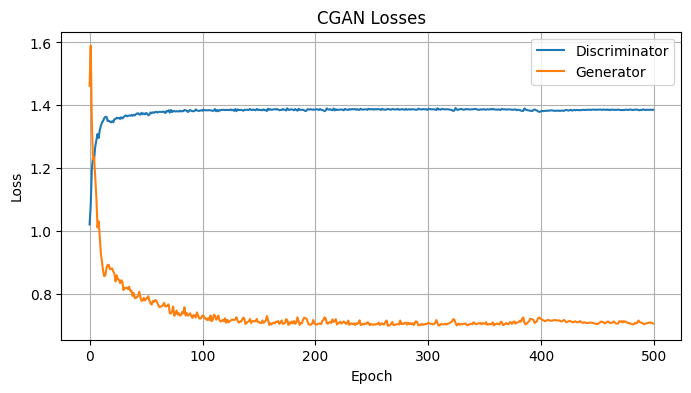

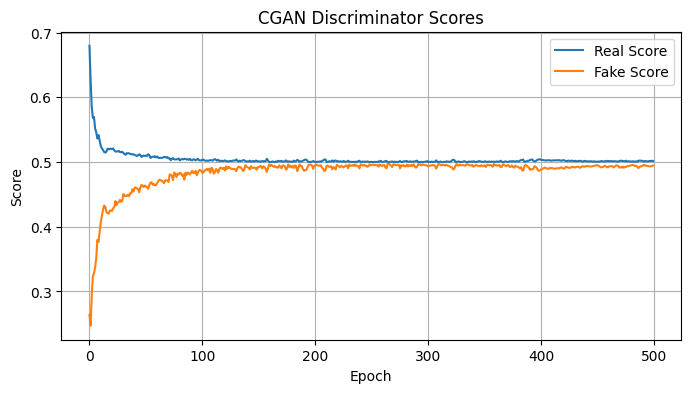

: 

In [ ]:
def plot_cgan_losses(d, g):
    plt.figure(figsize=(8, 4))
    plt.plot(d, label="Discriminator")
    plt.plot(g, label="Generator")
    plt.legend()
    plt.title("CGAN Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


def plot_cgan_scores(r, f):
    plt.figure(figsize=(8, 4))
    plt.plot(r, label="Real Score")
    plt.plot(f, label="Fake Score")
    plt.legend()
    plt.title("CGAN Discriminator Scores")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.grid(True)
    plt.show()

plot_cgan_losses(D_losses, G_losses)
plot_cgan_scores(real_scores, fake_scores)
